In [28]:
import numpy as np
import seaborn as sns
import pandas as pd
import os

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error as rmse

from sklearn.linear_model import LinearRegression


from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler


In [29]:
def to_csv(df, path):
    # Prepend dtypes to the top of df (from https://stackoverflow.com/a/43408736/7607701)
    df.loc[-1] = df.dtypes
    df.index = df.index + 1
    df.sort_index(inplace=True)
    # Then save it to a csv
    df.to_csv(path, index=False)

def read_csv(path):
    # Read types first line of csv
    dtypes = {key:value for (key,value) in pd.read_csv(path,    
              nrows=1).iloc[0].to_dict().items() if 'date' not in value}

    parse_dates = [key for (key,value) in pd.read_csv(path, 
                   nrows=1).iloc[0].to_dict().items() if 'date' in value]
    # Read the rest of the lines with the types from above
    return pd.read_csv(path, dtype=dtypes, parse_dates=parse_dates, skiprows=[1])

In [ ]:
by_day_data = '../data/schedule_data/processed_data/by_day_short_and_long/'
by_day_data_list_train = [x for x in os.listdir(by_day_data) if 'train.csv' in x]
dtypes = pd.read_csv(f'{os.path.join(by_day_data,by_day_data_list_train[0])}', nrows=1).iloc[0].to_dict()

train_daily_df = read_csv(by_day_data+by_day_data_list_train[0])
train_daily_df = train_daily_df[train_daily_df['date'].between(pd.Timestamp('2024-07-30'), pd.Timestamp('2025-09-01'), inclusive='left')]


by_day_data_list_test = [x for x in os.listdir(by_day_data) if 'test.csv' in x]
dtypes = pd.read_csv(f'{os.path.join(by_day_data,by_day_data_list_test[0])}', nrows=1).iloc[0].to_dict()

test_daily_df = read_csv(by_day_data+by_day_data_list_test[0])



In [31]:
# I want to add daily weather data, first read it all into a dataframe

## Since we have already decided on the features we want to use, we will only read those columns in
weather=pd.read_csv('../data/raw_data/Weatherstats_data/weatherstats_toronto_daily.csv', usecols=['date','avg_temperature', 'avg_wind_speed','avg_visibility', 'avg_health_index', 'rain','snow_on_ground', 'daylight'])
#drop columns that consist exclusively of NaNs
weather.dropna(axis=1, how='all', inplace=True)
#Convert date from string to datetime type
weather.date = weather.date.apply(pd.Timestamp)



In [32]:
# Now I will merge the weather data into the training and testing dataframes

for name, df in [("train df", train_daily_df),( "test df", test_daily_df)]:
    
    df = df.copy()
    df.date = df.date.apply(pd.Timestamp)
    df = df.rename(columns={
    'delay time (5,19]':'dt_short', 
    'delay time (19,120]':'dt_long', 
    'EB/WB':'dir'
    })

    # We will also add a column for the transformed bunching 
    df['log_bunch'] = np.log1p(df['bunch'])

    ## Turn stop information and direction into categorical features.
    df['stop']=df['stop'].astype('category')
    df['dir']=df['dir'].astype('category')



    first_date = df['date'].min()
    last_date = df['date'].max()
    temp_weather = weather[weather['date'].between(first_date,last_date)]
    

    df = pd.merge(df, temp_weather, on='date')

    # Fill any n/a values with zeros
    
    df.fillna(0, inplace=True)
   
    if name == "train df":
        train_daily_df = df
    else:
        test_daily_df = df

TypeError: Cannot setitem on a Categorical with a new category (0), set the categories first

In [ ]:
train_daily_df.tail()

,date,dir,stop,bunch,gap,dt_short,dt_long,No. of Veh,Run time (min),Term time (min),...,RT dist (km),Interruption,log_bunch,avg_temperature,avg_wind_speed,avg_visibility,avg_health_index,rain,snow_on_ground,daylight
58103,2025-08-31,W,Coxwell Ave at Lower Gerrard St East,0,0,0.000000,0.000000,14.8,135.6,13.2,...,30.13,0,0.000000,16.39,8.5,24100,2.0,0.0,0.0,13.25
58104,2025-08-31,W,Coxwell Ave at Gerrard St East,3,10,151.816667,48.600000,14.8,135.6,13.2,...,30.13,0,1.386294,16.39,8.5,24100,2.0,0.0,0.0,13.25
58105,2025-08-31,W,Main St at Gerrard St East,0,0,0.000000,0.000000,14.8,135.6,13.2,...,30.13,0,0.000000,16.39,8.5,24100,2.0,0.0,0.0,13.25
58106,2025-08-31,W,Queens Park (Queen's Park Station),0,0,0.000000,0.000000,14.8,135.6,13.2,...,30.13,0,0.000000,16.39,8.5,24100,2.0,0.0,0.0,13.25
58107,2025-08-31,E,Leslie St,10,13,331.216667,99.083333,14.8,135.6,13.2,...,30.13,0,2.397895,16.39,8.5,24100,2.0,0.0,0.0,13.25


In [ ]:
weather.columns

Index(['date', 'avg_temperature', 'avg_wind_speed', 'avg_visibility',
       'avg_health_index', 'rain', 'snow_on_ground', 'daylight'],
      dtype='object')

In [ ]:
features = ['dir', 'log_bunch', 'bunch', 'gap', 'Interruption']+weather.columns.to_list()
targets = [x for x in train_daily_df.columns if 'dt_' in x]

In [ ]:
corr_matrix = train_daily_df[features+targets].select_dtypes(np.number).corr()

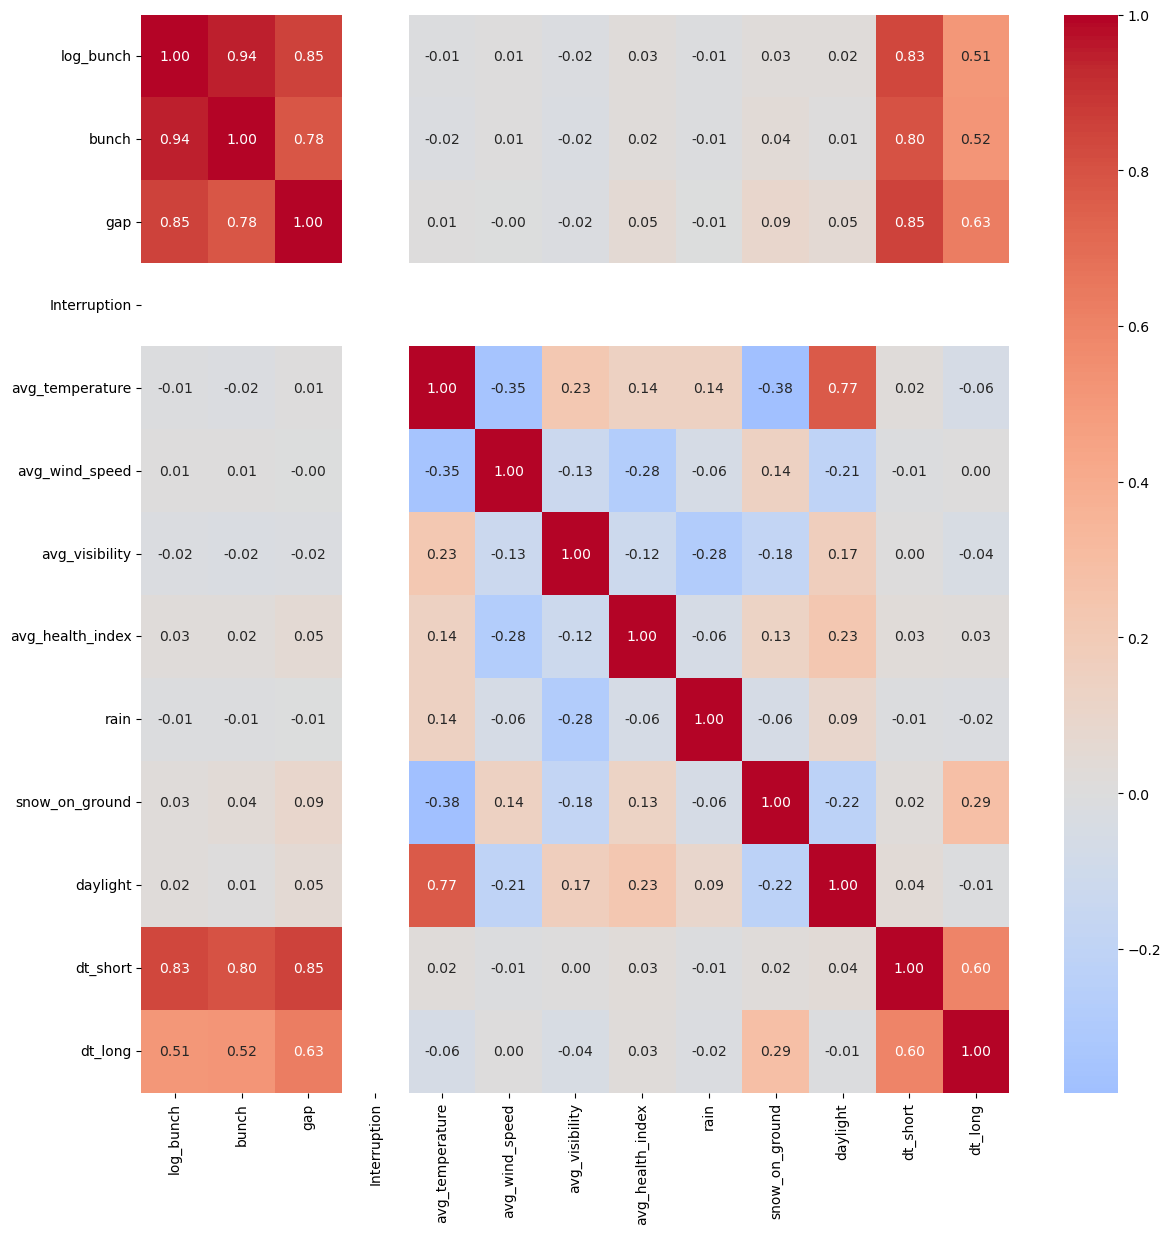

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,14))
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            fmt='.2f')
plt.show()

In [ ]:
final_models = {
    "raw_linear": {
        "targets": {"dt_long": "dt_long"},
        "cat features": ['dir', 'stop'],
        "num features": ['bunch', 'avg_temperature', 'avg_wind_speed','avg_visibility', 
                     'avg_health_index', 'rain','snow_on_ground', 
                     'daylight']
    },
    "log_bunch_linear": {
         "targets": {"dt_short": "dt_short"},
        "cat features": ['dir', 'stop'],
        "num features": ['log_bunch', 'avg_temperature', 'avg_wind_speed','avg_visibility', 
                     'avg_health_index', 'rain','snow_on_ground', 
                     'daylight']
    }
}

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

## Linear regression model 

## Just in case, lets make sure the dates are in order: 

## Modeling configurations with different choices of features and transformations: 



lin_loss = dict()
lin_R2_score = dict()


for model_name, config in final_models.items():
    num_features = config["num features"]
    cat_features = config["cat features"]
    features = num_features + cat_features

    preprocessor = ColumnTransformer(
            transformers=[
                ("std_scale", StandardScaler(), num_features),
                ("one_hot_encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features)
            ],
            remainder="drop"
        )


    for target_name, target_col in config["targets"].items():
        
        X_train = train_daily_df[features].copy()
        X_test = test_daily_df[features].copy()

        y_train = train_daily_df[target_col].copy()
        y_test = test_daily_df[target_name].copy()

    ## One-hot encode categorical variables

        model_pipe = Pipeline(steps=[
            ("preprocess", preprocessor),
            ("model", LinearRegression())
        ])

            
            
        model_pipe.fit(X_train, y_train)
        y_pred = model_pipe.predict(X_test)

## Back transform the transformed targets for comparison
        if "log" in target_col:
            y_pred = np.expm1(y_pred)

        lin_R2_score[(model_name, target_name)] = r2_score(y_test, y_pred)
        lin_loss[(model_name, target_name)] = rmse(y_test, y_pred)

            
        coefs = pd.Series(model_pipe.named_steps["model"].coef_, index=model_pipe.named_steps["preprocess"].get_feature_names_out())

        coefs_sorted = coefs.reindex(coefs.abs().sort_values(ascending=False).index)
        print(coefs_sorted)

        plt.figure()
        coefs_sorted.head(10).plot(kind='barh')
        plt.title(f"{model_name}: Top Feature Effects for {target_col}")
        plt.xlabel("Standardized Coefficient")
        plt.gca().invert_yaxis()
        plt.show()

for model_name in final_models.keys():
    for dt in ['dt_short', 'dt_long']:
        print(f'{model_name} {dt} rmse: {np.array([val for key, val in lin_loss.items() if key[0] == model_name and key[1] == dt])}')
        print(f'{model_name} {dt} R^2 score: {np.array([val for key, val in lin_R2_score.items() if key[0] == model_name and key[1] == dt])}')


ValueError: Found array with 0 sample(s) (shape=(0, 8)) while a minimum of 1 is required by StandardScaler.

(-800.0, 1000.0)

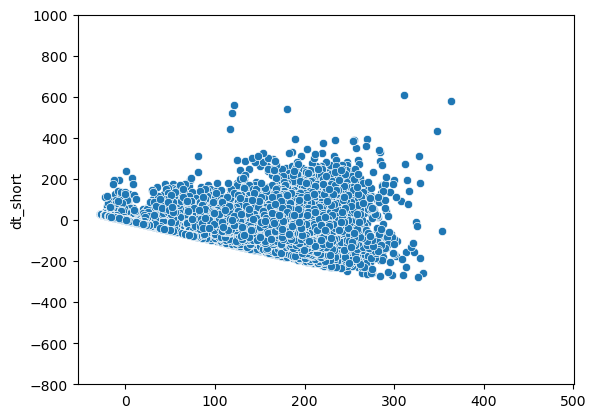

In [ ]:
y_resid = y_test - y_pred

sns.scatterplot(x = y_pred,y = y_resid)
plt.ylim(-800,1000)

In [ ]:

final_models = {
    "raw_linear": {
        "target": {"dt_long": "dt_long"},
        "features": ['bunch', 'avg_temperature', 
                     'avg_wind_speed','avg_visibility', 
                     'avg_health_index', 'rain','snow_on_ground', 
                     'daylight', 'dir', 'stop']
    },
    "log_bunch_linear": {
         "target": {"dt_short": "dt_short"},
        "features": ['log_bunch', 'avg_temperature', 
                     'avg_wind_speed','avg_visibility', 
                     'avg_health_index', 'rain','snow_on_ground', 
                     'daylight', 'dir', 'stop']
    }
}
## Turn stop information and direction into categorical features.
daily_df['stop']=daily_df['stop'].astype('category')
daily_df['dir']=daily_df['dir'].astype('category')

## Log Transformations of features/targets 


daily_df['log_dt_short'] = np.log1p(daily_df['dt_short'])
daily_df['log_dt_long'] = np.log1p(daily_df['dt_long'])

## Modeling configurations with different choices of features and transformations: 

models = {
    "raw_linear": {
        "targets": {"dt_short": "dt_short", 
                    "dt_long": "dt_long"},
        "features": ['bunch', 'avg_temperature', 
                     'avg_wind_speed','avg_visibility', 
                     'avg_health_index', 'rain','snow_on_ground', 
                     'daylight', 'dir', 'stop']
    },
    "log_targets_linear": {
         "targets": {"dt_short": "log_dt_short", 
                     "dt_long": "log_dt_long"},
        "features": ['bunch', 'avg_temperature', 
                     'avg_wind_speed','avg_visibility', 
                     'avg_health_index', 'rain','snow_on_ground', 
                     'daylight', 'dir', 'stop']
    }, 
    "log_log_linear": {
         "targets": {"dt_short": "log_dt_short", 
                     "dt_long": "log_dt_long"},
        "features": ['log_bunch', 'avg_temperature', 
                     'avg_wind_speed','avg_visibility', 
                     'avg_health_index', 'rain','snow_on_ground', 
                     'daylight', 'dir', 'stop']
    },
    "log_bunch_linear": {
         "targets": {"dt_short": "dt_short", 
                     "dt_long": "dt_long"},
        "features": ['log_bunch', 'avg_temperature', 
                     'avg_wind_speed','avg_visibility', 
                     'avg_health_index', 'rain','snow_on_ground', 
                     'daylight', 'dir', 'stop']
    }
}



lin_loss = dict()
lin_R2_score = dict()

## Just in case, lets make sure the dates are in order: 

daily_df = daily_df.sort_values("date").reset_index(drop=True)
tss = TimeSeriesSplit(n_splits=5, test_size=30)

for model_name, config in models.items():
    features = config["features"]
    
    for target in ['dt_short', 'dt_long']:
        target_col = config["targets"][target]
        
        for idx, (tss_train, tss_test) in enumerate(tss.split(daily_df, daily_df.date)):
            df_train = daily_df.iloc[tss_train]
            df_test = daily_df.iloc[tss_test]

            X_train = df_train[features].copy()
            X_test = df_test[features].copy()

            y_train = df_train[target_col].copy()
            y_test = df_test[target].copy()

    ## One-hot encode categorical variables

            X_train = pd.get_dummies(X_train, columns=['dir','stop'], drop_first=False)
            X_test = pd.get_dummies(X_test, columns=['dir','stop'], drop_first=False)

    ## Make sure the columns line up 
            X_test = X_test.reindex(columns=X_train.columns, fill_value = 0)

            
            model = LinearRegression()
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

## Back transform the transformed targets for comparison
            if "log" in target_col:
                y_pred = np.expm1(y_pred)

            lin_R2_score[(model_name, target, idx)] = r2_score(y_test, y_pred)
            lin_loss[(model_name, target, idx)] = rmse(y_test, y_pred)
       

for model_name in models.keys():
    for dt in ['dt_short', 'dt_long']:
        print(f'{model_name} {dt} rmse mean: {np.array([val for key, val in lin_loss.items() if key[0] == model_name and key[1] == dt]).mean()}')
        print(f'{model_name} {dt} rmse std: {np.array([val for key, val in lin_loss.items() if key[0] == model_name and key[1] == dt]).std()}')
        print(f'{model_name} {dt} average R^2 score: {np.array([val for key, val in lin_R2_score.items() if key[0] == model_name and key[1] == dt]).mean()}')
        print(f'{model_name} {dt} R^2 score std: {np.array([val for key, val in lin_R2_score.items() if key[0] == model_name and key[1] == dt]).std()}\n')

raw_linear dt_short rmse mean: 107.56882818315994
raw_linear dt_short rmse std: 18.271543425612354
raw_linear dt_short average R^2 score: 0.48597751983372006
raw_linear dt_short R^2 score std: 0.1172081337393741

raw_linear dt_long rmse mean: 76.75964037432432
raw_linear dt_long rmse std: 38.09121900979524
raw_linear dt_long average R^2 score: 0.23277113485861528
raw_linear dt_long R^2 score std: 0.3149186987130321

log_targets_linear dt_short rmse mean: 156.17566184588821
log_targets_linear dt_short rmse std: 23.160292220119334
log_targets_linear dt_short average R^2 score: -0.08300078944367636
log_targets_linear dt_short R^2 score std: 0.21605112361844137

log_targets_linear dt_long rmse mean: 94.0504127540281
log_targets_linear dt_long rmse std: 55.708757078655985
log_targets_linear dt_long average R^2 score: 0.03229445677980507
log_targets_linear dt_long R^2 score std: 0.10757069138284125

log_log_linear dt_short rmse mean: 126.21658383484944
log_log_linear dt_short rmse std: 22.77

In [ ]:
## This is a bit overwhelming, so I am going to plot this info in a graph instead so that we can choose the best ones to do regularization

## First, put all of the results for each model and each of the two features into a data frame 
results_dict = []

for key, val in lin_loss.items():
    results_dict.append(
        {
            "model": key[0],
            "target": key[1],
            "fold": key[2],
            "rmse": val,
            "r2": lin_R2_score[(key[0], key[1], key[2])]
        }
    )

results_df = pd.DataFrame(results_dict) 

# Next we will separate the two targets and take the average scores for each of the 4 models and plot the results. We will use this to determine the model to use for regularization

for target in ["dt_short", "dt_long"]:
    target_df = results_df[results_df["target"] == target]

    summary = (
        target_df
        .groupby(["model"])[["rmse", "r2"]]
        .mean()
    )

    #Sort lowest to highest
    summary_rmse = summary.sort_values("rmse", ascending=True)
    summary_rmse["rmse"].plot(kind="bar")
    plt.title(f"RMSE comparison: {target}")
    plt.ylabel("RMSE")
    plt.show()

    ## Sort highest to lowest
    summary_r2 = summary.sort_values("r2", ascending=False)
    summary_r2["r2"].plot(kind="bar")
    plt.title(f"R^2 comparison: {target}")
    plt.ylabel("R^2")
    plt.axhline(0)
    plt.show()


KeyError: 'target'

In [ ]:
## Now we will stick with the log_bunch_linear model (best for dt_short) and raw_linear model (best for dt_long)
best_models = {
    "raw_linear": {
        "targets": {"dt_short": "dt_short", 
                    "dt_long": "dt_long"},
        "features": ['bunch', 'avg_temperature', 
                     'avg_wind_speed','avg_visibility', 
                     'avg_health_index', 'rain','snow_on_ground', 
                     'daylight', 'dir', 'stop']
    },
    
    "log_bunch_linear": {
         "targets": {"dt_short": "dt_short", 
                     "dt_long": "dt_long"},
        "features": ['log_bunch', 'avg_temperature', 
                     'avg_wind_speed','avg_visibility', 
                     'avg_health_index', 'rain','snow_on_ground', 
                     'daylight', 'dir', 'stop']
    }
}


In [ ]:
## Next we will do some Ridge and Lasso regularization


from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


reg_loss = dict()
reg_R2_score = dict()
best_params = dict()

num_splits = 5
outer_cv = TimeSeriesSplit(n_splits=num_splits, test_size=30)
inner_cv = TimeSeriesSplit(n_splits=3)

nested_results = []
best_params = {}

for model_name, config in best_models.items():
    features = config["features"]
    
    for target_name, target_col in config["targets"].items():
        X = daily_df[features].copy()
        y = daily_df[target_col].copy()

        numeric_features = [col for col in features if col not in ["dir", "stop"]]
        categorical_features = [col for col in features if col in ["dir", "stop"]]

    #Preprocess the columns 
        preprocessor = ColumnTransformer(
            transformers=[
                ("std_scale", StandardScaler(), numeric_features),
                ("one_hot_encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
            ],
            remainder="drop"
        )

        ridge_pipe = Pipeline(steps=[
            ("preprocess", preprocessor),
            ("model", Ridge(random_state= 17))
        ])

        lasso_pipe = Pipeline(steps=[
            ("preprocess", preprocessor),
            ("model", Lasso(random_state= 17, max_iter=10000))
        ])

        ridge_grid = {
            "model__alpha": np.logspace(-3, 3, 13)
        }

        lasso_grid = {
            "model__alpha": np.logspace(-3, 0, 9)
        }


# To store the best parameters
        best_params[("ridge_tuned", model_name, target_name)] = []
        best_params[("lasso_tuned", model_name, target_name)] = []


    # Outer Folds
        for fold, (outer_train_idx, outer_test_idx) in enumerate(outer_cv.split(X), start=1):
            X_train, X_test = X.iloc[outer_train_idx], X.iloc[outer_test_idx]
            y_train, y_test = y.iloc[outer_train_idx], y.iloc[outer_test_idx]

    ## Ridge with inner tuning

            ridge_search = GridSearchCV(
                estimator=ridge_pipe,
                param_grid=ridge_grid,
                scoring="neg_root_mean_squared_error",
                cv=inner_cv,
                n_jobs=-1
            )
            ridge_search.fit(X_train, y_train)
            y_pred_ridge = ridge_search.best_estimator_.predict(X_test)

            ridge_rmse = rmse(y_test, y_pred_ridge)
            ridge_r2 = r2_score(y_test, y_pred_ridge)

            nested_results.append({
                "regularization": "ridge_tuned",
                "model": model_name,
                "target": target_name,
                "fold": fold,
                "rmse": ridge_rmse,
                "r2": ridge_r2
            })

            best_params[("ridge_tuned", model_name, target_name)].append(ridge_search.best_params_)



    ## Lasso with inner tuning
            lasso_search = GridSearchCV(
                estimator=lasso_pipe,
                param_grid=lasso_grid,
                scoring="neg_root_mean_squared_error",
                cv=inner_cv,
                n_jobs=-1
            )
            lasso_search.fit(X_train, y_train)
            y_pred_lasso = lasso_search.best_estimator_.predict(X_test)


            lasso_rmse = rmse(y_test, y_pred_lasso)
            lasso_r2 = r2_score(y_test, y_pred_lasso)

            nested_results.append({
                "regularization": "lasso_tuned",
                "model": model_name,
                "target": target_name,
                "fold": fold,
                "rmse": lasso_rmse,
                "r2": lasso_r2
            })

            best_params[("lasso_tuned", model_name, target_name)].append(lasso_search.best_params_)

            print(
                f"{model_name}, {target_name}, Fold {fold}: "
                f"ridge RMSE={ridge_rmse:.2f}, ridge R^2={ridge_r2:.2f}, best alpha={ridge_search.best_params_['model__alpha']}; "
                f"lasso RMSE={lasso_rmse:.2f}, lasso R^2={lasso_r2:.2f}, best alpha={lasso_search.best_params_['model__alpha']}"
            )

nested_results_df = pd.DataFrame(nested_results)

final_reg_summary = (
    nested_results_df
    .groupby(["regularization", "model", "target"])
    .agg(
        mean_rmse=("rmse", "mean"),
        std_rmse=("rmse", "std"),
        mean_r2=("r2", "mean"),
        std_r2=("r2", "std")
    )
    .reset_index()
)
## Summary for the outer Folds

alpha_summary = []
for key, val in best_params.items():
    alphas = [d["model__alpha"] for d in val]
    
    alpha_summary.append({
        "regularization": key[0],
        "model": key[1],
        "target": key[2],
        "mean_alpha": np.mean(alphas),
        "std_alpha": np.std(alphas),
        "all_alphas": alphas
    })

alpha_df = pd.DataFrame(alpha_summary)


raw_linear, dt_short, Fold 1: ridge RMSE=87.27, ridge R^2=0.62, best alpha=100.0; lasso RMSE=88.20, lasso R^2=0.61, best alpha=0.07498942093324558
raw_linear, dt_short, Fold 2: ridge RMSE=131.71, ridge R^2=0.42, best alpha=100.0; lasso RMSE=132.58, lasso R^2=0.41, best alpha=0.07498942093324558
raw_linear, dt_short, Fold 3: ridge RMSE=124.07, ridge R^2=0.32, best alpha=100.0; lasso RMSE=125.58, lasso R^2=0.30, best alpha=0.07498942093324558
raw_linear, dt_short, Fold 4: ridge RMSE=108.97, ridge R^2=0.45, best alpha=100.0; lasso RMSE=110.16, lasso R^2=0.44, best alpha=0.07498942093324558
raw_linear, dt_short, Fold 5: ridge RMSE=87.28, ridge R^2=0.61, best alpha=100.0; lasso RMSE=87.52, lasso R^2=0.61, best alpha=0.07498942093324558
raw_linear, dt_long, Fold 1: ridge RMSE=63.15, ridge R^2=0.47, best alpha=0.001; lasso RMSE=63.16, lasso R^2=0.47, best alpha=0.001
raw_linear, dt_long, Fold 2: ridge RMSE=151.14, ridge R^2=0.39, best alpha=0.001; lasso RMSE=151.16, lasso R^2=0.39, best alpha

In [ ]:
## Now we will look at the alphas for the log_bunch_linear model (best for dt_short) and raw_linear model (best for dt_long)

## for dt_short, ridge seems to improve things more than lasso for both log_bunch and raw_linear, but dt_long doesn't really benefit from either. 

## However, for dt_short the ridge doesn't actually improve the scores compared to the initial model.... so let's just proceed without the regularization. 

In [ ]:
## ## Once again... is a bit overwhelming, so I am going to plot this info in a graph instead so that we can choose the best regularizations


In [ ]:


## One Last thing I will do is try to prune the features a bit in line with the XGBoost pruning 


filtered_models = {
    "raw_linear": {
        "targets": {"dt_short": "dt_short", 
                    "dt_long": "dt_long"},
        "features": ['bunch', 'avg_wind_speed', 'avg_visibility', 'avg_health_index', 'rain', 'snow_on_ground', 'daylight', 'dir', 'stop']

    },
    
    "log_bunch_linear": {
         "targets": {"dt_short": "dt_short", 
                     "dt_long": "dt_long"},
        "features": ['log_bunch', 'avg_wind_speed', 'avg_visibility', 'avg_health_index', 'rain', 'snow_on_ground', 'daylight', 'dir', 'stop']

    }
}


filt_lin_loss = dict()
filt_lin_R2_score = dict()

## Just in case, lets make sure the dates are in order: 

daily_df = daily_df.sort_values("date").reset_index(drop=True)


for model_name, config in filtered_models.items():
    features = config["features"]
    
    for target in ['dt_short', 'dt_long']:
        target_col = config["targets"][target]
        
        for idx, (tss_train, tss_test) in enumerate(tss.split(daily_df, daily_df.date)):
            df_train = daily_df.iloc[tss_train]
            df_test = daily_df.iloc[tss_test]

            X_train = df_train[features].copy()
            X_test = df_test[features].copy()

            y_train = df_train[target_col].copy()
            y_test = df_test[target].copy()

    ## One-hot encode categorical variables

            X_train = pd.get_dummies(X_train, columns=['dir','stop'], drop_first=False)
            X_test = pd.get_dummies(X_test, columns=['dir','stop'], drop_first=False)

    ## Make sure the columns line up 
            X_test = X_test.reindex(columns=X_train.columns, fill_value = 0)

            
            model = LinearRegression()
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

## Back transform the transformed targets for comparison
            if "log" in target_col:
                y_pred = np.expm1(y_pred)

            filt_lin_R2_score[(model_name, target, idx)] = r2_score(y_test, y_pred)
            filt_lin_loss[(model_name, target, idx)] = rmse(y_test, y_pred)
       

for model_name in filtered_models.keys():
    for dt in ['dt_short', 'dt_long']:
        print(f'{model_name} {dt} rmse mean: {np.array([val for key, val in filt_lin_loss.items() if key[0] == model_name and key[1] == dt]).mean()}')
        print(f'{model_name} {dt} rmse std: {np.array([val for key, val in filt_lin_loss.items() if key[0] == model_name and key[1] == dt]).std()}')
        print(f'{model_name} {dt} average R^2 score: {np.array([val for key, val in filt_lin_R2_score.items() if key[0] == model_name and key[1] == dt]).mean()}')
        print(f'{model_name} {dt} R^2 score std: {np.array([val for key, val in filt_lin_R2_score.items() if key[0] == model_name and key[1] == dt]).std()}\n')


raw_linear dt_short rmse mean: 107.46628656922451
raw_linear dt_short rmse std: 14.963121490246069
raw_linear dt_short average R^2 score: 0.48553050596826725
raw_linear dt_short R^2 score std: 0.09740863772162943

raw_linear dt_long rmse mean: 78.40978820857927
raw_linear dt_long rmse std: 36.94736727966232
raw_linear dt_long average R^2 score: -0.137742618201048
raw_linear dt_long R^2 score std: 0.5950787783146922

log_bunch_linear dt_short rmse mean: 90.22173992038158
log_bunch_linear dt_short rmse std: 12.979369443220856
log_bunch_linear dt_short average R^2 score: 0.6383558709308652
log_bunch_linear dt_short R^2 score std: 0.06550806217772319

log_bunch_linear dt_long rmse mean: 81.96434569005993
log_bunch_linear dt_long rmse std: 32.23148584598032
log_bunch_linear dt_long average R^2 score: -0.4267705745056343
log_bunch_linear dt_long R^2 score std: 0.901194485412403



In [ ]:
print(results_df.head(10))
print(results_df["model"].unique())


        model    target  fold        rmse        r2
0  raw_linear  dt_short     0   86.512671  0.627962
1  raw_linear  dt_short     1  130.901134  0.423924
2  raw_linear  dt_short     2  124.044085  0.318139
3  raw_linear  dt_short     3  109.015477  0.450418
4  raw_linear  dt_short     4   87.370774  0.609445
5  raw_linear   dt_long     0   63.149914  0.473941
6  raw_linear   dt_long     1  151.138695  0.394665
7  raw_linear   dt_long     2   70.783888  0.296201
8  raw_linear   dt_long     3   49.786438  0.385959
9  raw_linear   dt_long     4   48.939267 -0.386911
<ArrowStringArray>
['raw_linear', 'log_targets_linear', 'log_log_linear', 'log_bunch_linear']
Length: 4, dtype: str


              model feature_set        rmse        r2  \
0  log_bunch_linear        full   90.572170  0.636657   
1  log_bunch_linear     reduced   90.221740  0.638356   
2        raw_linear        full  107.568828  0.485978   
3        raw_linear     reduced  107.466287  0.485531   

                        label  
0     log_bunch_linear (full)  
1  log_bunch_linear (reduced)  
2           raw_linear (full)  
3        raw_linear (reduced)  


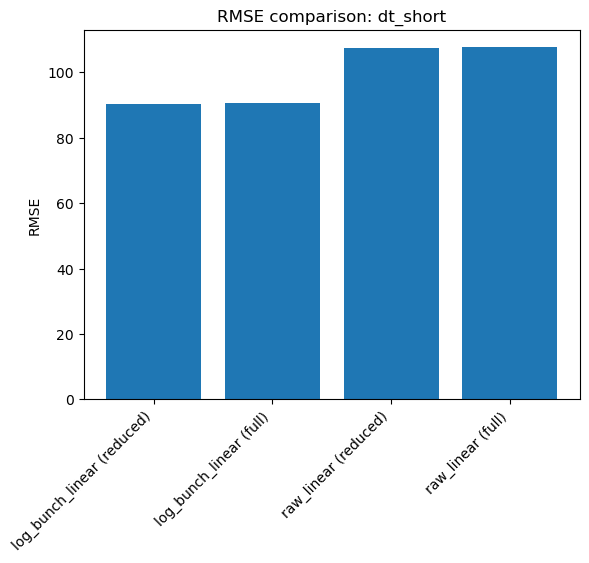

              model feature_set        rmse        r2  \
1  log_bunch_linear     reduced   90.221740  0.638356   
0  log_bunch_linear        full   90.572170  0.636657   
3        raw_linear     reduced  107.466287  0.485531   
2        raw_linear        full  107.568828  0.485978   

                        label  
1  log_bunch_linear (reduced)  
0     log_bunch_linear (full)  
3        raw_linear (reduced)  
2           raw_linear (full)  


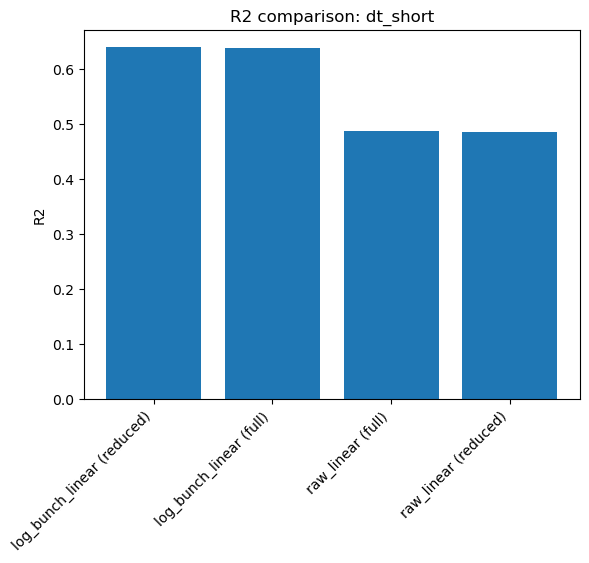

              model feature_set        rmse        r2  \
1  log_bunch_linear     reduced   90.221740  0.638356   
0  log_bunch_linear        full   90.572170  0.636657   
2        raw_linear        full  107.568828  0.485978   
3        raw_linear     reduced  107.466287  0.485531   

                        label  
1  log_bunch_linear (reduced)  
0     log_bunch_linear (full)  
2           raw_linear (full)  
3        raw_linear (reduced)  
              model feature_set       rmse        r2  \
0  log_bunch_linear        full  79.675943  0.090717   
1  log_bunch_linear     reduced  81.964346 -0.426771   
2        raw_linear        full  76.759640  0.232771   
3        raw_linear     reduced  78.409788 -0.137743   

                        label  
0     log_bunch_linear (full)  
1  log_bunch_linear (reduced)  
2           raw_linear (full)  
3        raw_linear (reduced)  


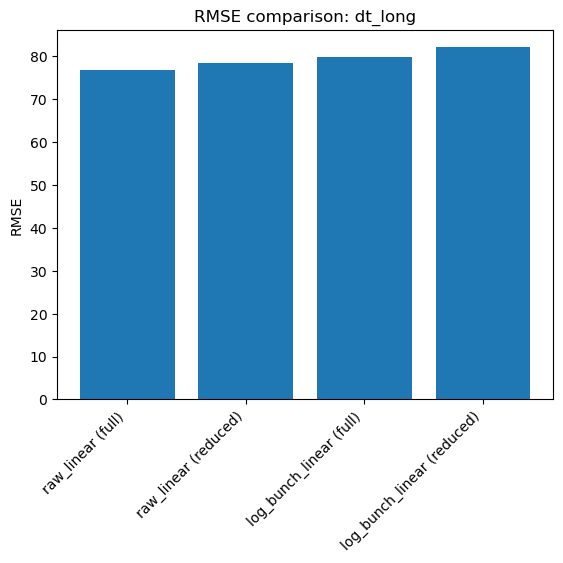

              model feature_set       rmse        r2  \
2        raw_linear        full  76.759640  0.232771   
3        raw_linear     reduced  78.409788 -0.137743   
0  log_bunch_linear        full  79.675943  0.090717   
1  log_bunch_linear     reduced  81.964346 -0.426771   

                        label  
2           raw_linear (full)  
3        raw_linear (reduced)  
0     log_bunch_linear (full)  
1  log_bunch_linear (reduced)  


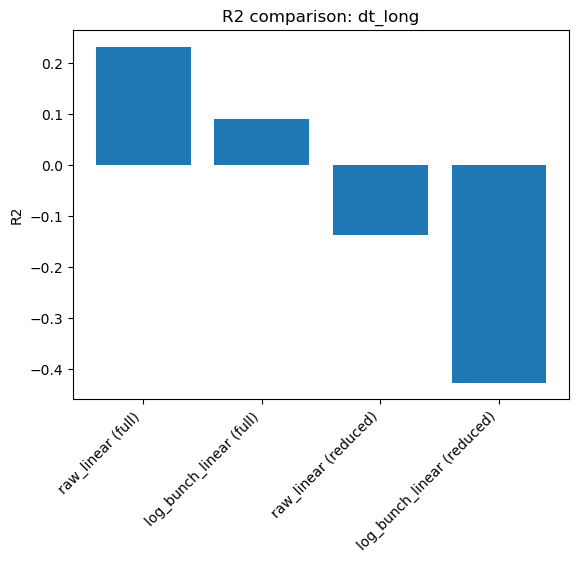

              model feature_set       rmse        r2  \
2        raw_linear        full  76.759640  0.232771   
0  log_bunch_linear        full  79.675943  0.090717   
3        raw_linear     reduced  78.409788 -0.137743   
1  log_bunch_linear     reduced  81.964346 -0.426771   

                        label  
2           raw_linear (full)  
0     log_bunch_linear (full)  
3        raw_linear (reduced)  
1  log_bunch_linear (reduced)  


In [ ]:
## First build a data frame for the two models we chose earlier along with the results



filt_results_dict = []

for key, val in filt_lin_loss.items():
    filt_results_dict.append(
        {
            "model": key[0],
            "target": key[1],
            "fold": key[2],
            "rmse": val,
            "r2": filt_lin_R2_score[(key[0], key[1], key[2])],
            "feature_set": "reduced"
        }
    )

filt_results_df = pd.DataFrame(filt_results_dict)


## Now build a dataframe for the original full-feature models but only for the two we decided to focus on
full_results_dict = []

for key, val in lin_loss.items():
    if key[0] in ["raw_linear", "log_bunch_linear"]:
        full_results_dict.append(
            {
                "model": key[0],
                "target": key[1],
                "fold": key[2],
                "rmse": val,
                "r2": lin_R2_score[(key[0], key[1], key[2])],
                "feature_set": "full"
            }
        )

full_results_df = pd.DataFrame(full_results_dict)


## Combine the two
combined_results_df = pd.concat(
    [full_results_df, filt_results_df],
    ignore_index=True
)

# Next we will separate the two targets and take the average scores for each of the 4 models and plot the results. We will use this to determine the model to use for regularization

for target in ["dt_short", "dt_long"]:
    target_df = combined_results_df[combined_results_df["target"] == target].copy()

    summary = (
        target_df
        .groupby(["model", "feature_set"])[["rmse", "r2"]]
        .mean()
        .reset_index()
    )

    summary["label"] = summary["model"] + " (" + summary["feature_set"] + ")"
    print(summary)

    #Sort lowest to highest
    summary_rmse = summary.sort_values("rmse", ascending=True)
    plt.bar(summary_rmse["label"], summary_rmse["rmse"])
    plt.title(f"RMSE comparison: {target}")
    plt.ylabel("RMSE")
    plt.xticks(rotation=45, ha='right')
    plt.show()
    print(summary_rmse)

    ## Sort highest to lowest
    summary_r2 = summary.sort_values("r2", ascending=False)
    plt.bar(summary_r2["label"], summary_r2["r2"])
    plt.title(f"R2 comparison: {target}")
    plt.ylabel("R2")
    plt.xticks(rotation=45, ha='right')
    plt.show()
    print(summary_r2)

In [ ]:
## This doesn't seem to make a difference for dt_short and while the R^2 score for the dt_long log_bunch model seems to do a bit better, the other models do much worse with this reduction so lets not change these either and stick with the entire feature set we had initially. 

## So based on everything we've seen so far it looks like the best models are log_bunch_linear for dt_short and raw_linear for dt_long with no regularization. Lets build our final model and train on the entire training set now


In [ ]:
final_models = {
    "raw_linear": {
        "target": {"dt_long": "dt_long"},
        "features": ['bunch', 'avg_temperature', 
                     'avg_wind_speed','avg_visibility', 
                     'avg_health_index', 'rain','snow_on_ground', 
                     'daylight', 'dir', 'stop']
    },
    "log_bunch_linear": {
         "target": {"dt_short": "dt_short"},
        "features": ['log_bunch', 'avg_temperature', 
                     'avg_wind_speed','avg_visibility', 
                     'avg_health_index', 'rain','snow_on_ground', 
                     'daylight', 'dir', 'stop']
    }
}


We use xgboost since it's a very flexible model that generalizes well. According to (https://stats.stackexchange.com/questions/338904/measures-of-ordinal-classification-error-for-ordinal-regression)[this post on Cross Validated], RMSE is the best measure of performance for ordinal classification when the classes are reasonably balanced, and MAE should not be used. Note that 'dt_long' is *not* balanced, and so we will have to come to an analysis of this with a different metric.

In [ ]:
# Let's try xgboost since it is a very flexible model
import xgboost as xgb
# First turn stop into a categorical feature.
daily_df['stop']=daily_df['stop'].astype('category')
daily_df['dir']=daily_df['dir'].astype('category')

loss = dict()
R2_score = dict()
features = ['bunch', 'gap', 'avg_temperature', 'avg_wind_speed', 'avg_visibility', 'avg_health_index', 'rain',
            'snow_on_ground',
            'daylight', 'dir', 'stop']

tss = TimeSeriesSplit(n_splits=5, test_size=30)
for target in ['dt_short', 'dt_long']:
    for idx, (tss_train, tss_test) in enumerate(tss.split(daily_df, daily_df.date)):
        df_train = daily_df.iloc[tss_train]
        df_test = daily_df.iloc[tss_test]

        model = xgb.XGBRegressor(objective='reg:squarederror',
                                n_estimators=200,
                                enable_categorical=True,
                                learning_rate=0.1,
                                max_depth=10,
                                reg_alpha=2,
                                reg_lambda=0,
                                seed=37)

        X_train = df_train[features]
        y_train = df_train[target]
        X_test = df_test[features]
        y_test = df_test[target]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        R2_score[target,idx] = r2_score(y_test, y_pred)
        loss[target,idx] = rmse(y_test, y_pred)

for dt in ['dt_short', 'dt_long']:
    print(f'{dt} rmse mean: {np.array([val for key,val in loss.items() if key[0] == dt]).mean()}')
    print(f'{dt} rmse std: {np.array([val for key,val in loss.items() if key[0] == dt]).std()}')
    print(f'{dt} average R^2 score: {np.array([val for key,val in R2_score.items() if key[0] == dt]).mean()}')
    print(f'{dt} R^2 score std: {np.array([val for key,val in R2_score.items() if key[0] == dt]).std()}\n')

dt_short rmse mean: 58.798915725531856
dt_short rmse std: 13.09872121588919
dt_short average R^2 score: 0.8378409350215339
dt_short R^2 score std: 0.07303505630187666

dt_long rmse mean: 66.95972016720661
dt_long rmse std: 37.186182473575265
dt_long average R^2 score: 0.29623802176661646
dt_long R^2 score std: 0.2716814998971146

